# Monthly Shampoo Sales Analysis
This notebook demonstrates time series forecasting using ARIMA and SARIMA models.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# Setting aesthetic parameters
sns.set_theme(style="whitegrid")

In [28]:
# Loading a built-in dataset alternative: Shampoo Sales
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv'
shampoo_data = pd.read_csv(url)

print("Initial Data Structure:")
display(shampoo_data.head())

Initial Data Structure:


,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


In [29]:
# Data Cleaning and Indexing
def parse_shampoo_date(x):
    # '1-01' -> Year 1, Month 01. Mapping to 1901 for valid datetime objects.
    parts = x.split('-')
    return pd.to_datetime(f'190{parts[0]}-{parts[1]}-01')

shampoo_data['Month'] = shampoo_data['Month'].apply(parse_shampoo_date)
shampoo_data.rename(columns={'Sales': 'Monthly_Sales'}, inplace=True)
shampoo_data.set_index('Month', inplace=True)

print(shampoo_data.info())
display(shampoo_data.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36 entries, 1901-01-01 to 1903-12-01
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Monthly_Sales  36 non-null     float64
dtypes: float64(1)
memory usage: 576.0 bytes
None


,Monthly_Sales
Month,
1901-01-01,266.0
1901-02-01,145.9
1901-03-01,183.1
1901-04-01,119.3
1901-05-01,180.3


In [30]:
# Visual Exploration using Plotly
# Reset index so 'Month' is a column for Plotly to use
fig = px.line(shampoo_data.reset_index(), x='Month', y='Monthly_Sales', title='Trends in Monthly Shampoo Sales',
              labels={'Monthly_Sales': 'Sales Volume', 'Month': 'Timeline'})
fig.show()

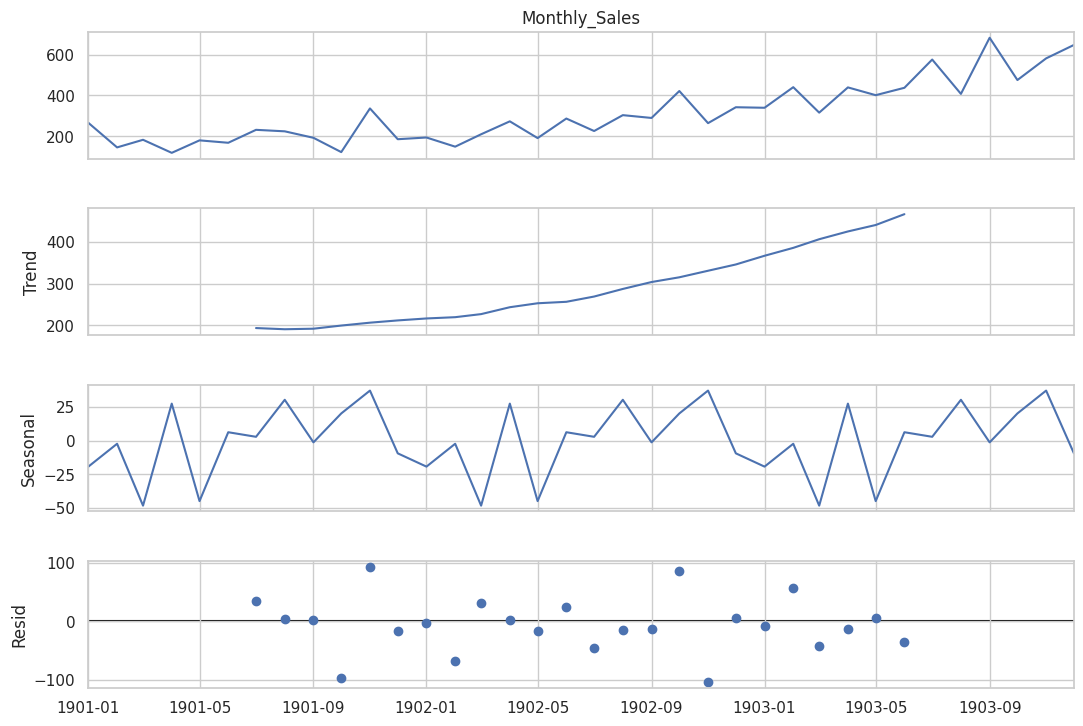

In [31]:
# Time Series Decomposition
analysis = seasonal_decompose(shampoo_data['Monthly_Sales'], model='additive', period=12)
fig_decomp = analysis.plot()
fig_decomp.set_size_inches(12, 8)
plt.show()

In [32]:
# Feature Engineering: Lags and Moving Averages
# index.year now works because index is a DatetimeIndex
shampoo_data['Year_Val'] = shampoo_data.index.year
shampoo_data['Prev_Month'] = shampoo_data['Monthly_Sales'].shift(1)
shampoo_data['Annual_Lag'] = shampoo_data['Monthly_Sales'].shift(12)
shampoo_data['MA_4'] = shampoo_data['Monthly_Sales'].rolling(window=4).mean()

display(shampoo_data.head(15))

,Monthly_Sales,Year_Val,Prev_Month,Annual_Lag,MA_4
Month,,,,,
1901-01-01,266.0,1901,NaN,NaN,NaN
1901-02-01,145.9,1901,266.0,NaN,NaN
1901-03-01,183.1,1901,145.9,NaN,NaN
1901-04-01,119.3,1901,183.1,NaN,178.575
1901-05-01,180.3,1901,119.3,NaN,157.150
1901-06-01,168.5,1901,180.3,NaN,162.800
1901-07-01,231.8,1901,168.5,NaN,174.975
1901-08-01,224.5,1901,231.8,NaN,201.275
1901-09-01,192.8,1901,224.5,NaN,204.400


In [33]:
# Stationarity Test (Augmented Dickey-Fuller)
def check_stationarity(timeseries):
    test_result = adfuller(timeseries)
    print(f'ADF Stat: {test_result[0]:.4f}')
    print(f'p-value: {test_result[1]:.4f}')
    if test_result[1] <= 0.05:
        print("Conclusion: Stationary")
    else:
        print("Conclusion: Non-Stationary")

check_stationarity(shampoo_data['Monthly_Sales'])

ADF Stat: 3.0601
p-value: 1.0000
Conclusion: Non-Stationary


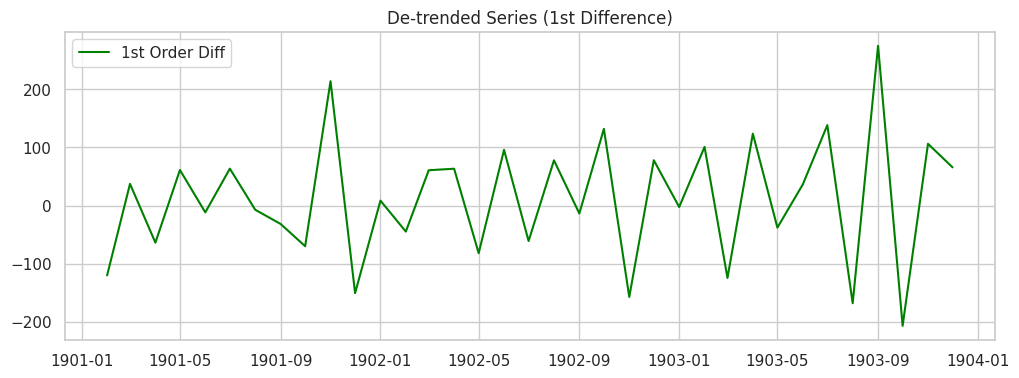

In [34]:
# Differencing to achieve stationarity
shampoo_data['Diff_Order1'] = shampoo_data['Monthly_Sales'].diff()

plt.figure(figsize=(12, 4))
plt.plot(shampoo_data['Diff_Order1'], label='1st Order Diff', color='green')
plt.title("De-trended Series (1st Difference)")
plt.legend()
plt.show()

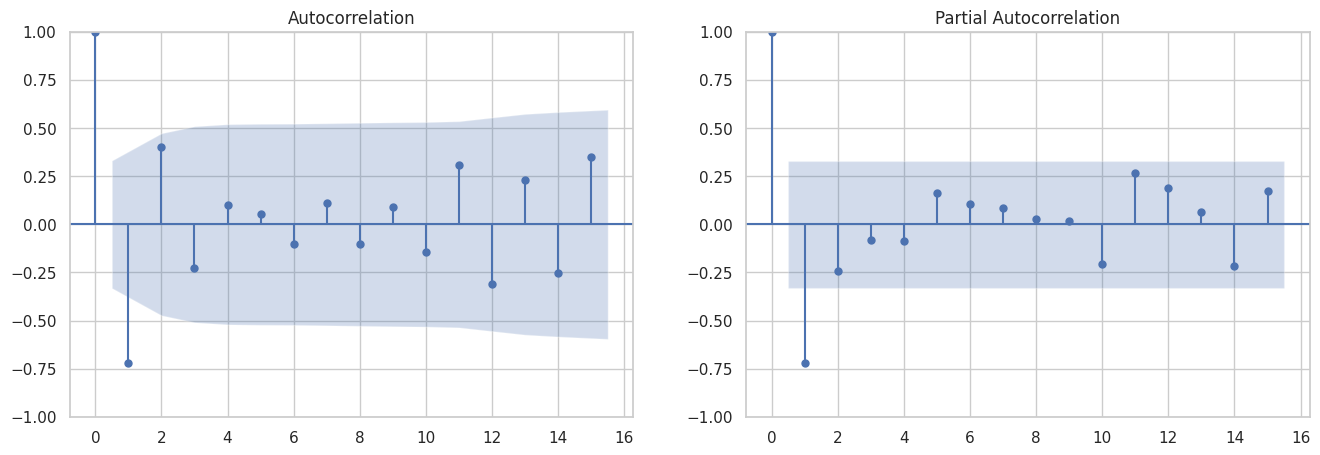

In [35]:
# Correlation Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(shampoo_data['Diff_Order1'].dropna(), lags=15, ax=axes[0])
plot_pacf(shampoo_data['Diff_Order1'].dropna(), lags=15, ax=axes[1])
plt.show()

In [36]:
# Re-splitting into Training and Validation sets
split_point = int(len(shampoo_data) * 0.8)
train_set = shampoo_data.iloc[:split_point]
test_set = shampoo_data.iloc[split_point:]

print(f'Training count: {len(train_set)}')
print(f'Testing count: {len(test_set)}')

Training count: 28
Testing count: 8


In [37]:
# Model 1: ARIMA
# Re-defining train/test to ensure they have the correct columns after cleaning
split_point = int(len(shampoo_data) * 0.8)
train_set = shampoo_data.iloc[:split_point]
test_set = shampoo_data.iloc[split_point:]

arima_config = (1, 1, 1)
model_1 = ARIMA(train_set['Monthly_Sales'], order=arima_config).fit()
arima_forecast = model_1.forecast(steps=len(test_set))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.



In [38]:
# Model 2: SARIMA
sarima_model = SARIMAX(train_set['Monthly_Sales'],
                       order=(1, 1, 1),
                       seasonal_order=(0, 1, 1, 12)).fit(disp=False)
sarima_forecast = sarima_model.forecast(steps=len(test_set))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency MS will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



In [39]:
# Performance Metrics
def calculate_error(y_true, y_pred, label):
    rmse_val = sqrt(mean_squared_error(y_true, y_pred))
    mae_val = mean_absolute_error(y_true, y_pred)
    print(f"--- {label} Performance ---")
    print(f"RMSE: {rmse_val:.2f}")
    print(f"MAE:  {mae_val:.2f}\n")

calculate_error(test_set['Monthly_Sales'], arima_forecast, "ARIMA")
calculate_error(test_set['Monthly_Sales'], sarima_forecast, "SARIMA")

--- ARIMA Performance ---
RMSE: 176.12
MAE:  143.62

--- SARIMA Performance ---
RMSE: 139.42
MAE:  108.81



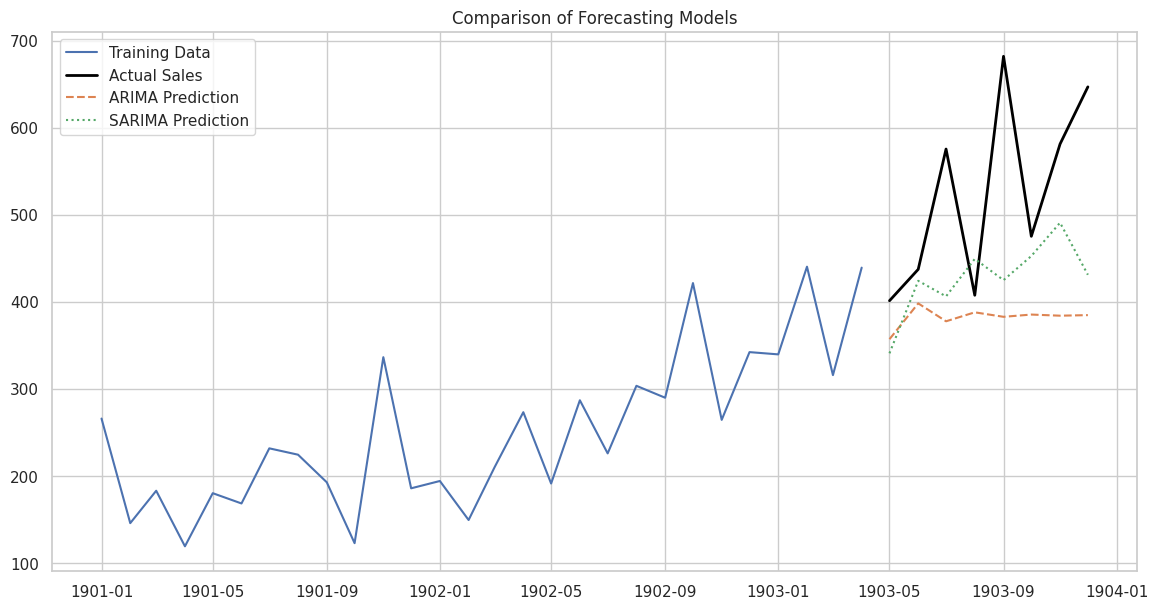

In [40]:
# Visualization of Results
plt.figure(figsize=(14, 7))
plt.plot(train_set.index, train_set['Monthly_Sales'], label='Training Data')
plt.plot(test_set.index, test_set['Monthly_Sales'], label='Actual Sales', color='black', lw=2)
plt.plot(test_set.index, arima_forecast, '--', label='ARIMA Prediction')
plt.plot(test_set.index, sarima_forecast, ':', label='SARIMA Prediction')

plt.title("Comparison of Forecasting Models")
plt.legend()
plt.show()

In [41]:
# Final Out-of-Sample Forecast
final_steps = 6
future_pred = sarima_model.forecast(steps=final_steps)
future_index = pd.date_range(shampoo_data.index[-1], periods=final_steps + 1, freq='MS')[1:]

print('Predicted Sales for next 6 months:')
print(pd.Series(future_pred.values, index=future_index))

Predicted Sales for next 6 months:
1904-01-01    340.915547
1904-02-01    424.176861
1904-03-01    406.289108
1904-04-01    449.380326
1904-05-01    424.957979
1904-06-01    452.652408
Freq: MS, dtype: float64
